### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import ttest_rel
import statsmodels.api as sm

sns.set(style="whitegrid")

### Load Main Dataset

In [2]:
base_dir = os.getcwd()
table_1_5_path = os.path.join(base_dir, "Datasets/table_1_5_cleaned.csv")
df = pd.read_csv(table_1_5_path)

print("Table 1.5 loaded successfully")
print(df.head())
print(df.info())

Table 1.5 loaded successfully
                                       Cause  Deaths  Year   Sex
0  Intestinal infectious diseases  (A00-A09)   236.0  2015  Male
1                              Cholera (A00)     0.0  2015  Male
2       Typhoid and paratyphoid fevers (A01)     0.0  2015  Male
3          Other salmonella infections (A02)    13.0  2015  Male
4                          Shigellosis (A03)     0.0  2015  Male
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64410 entries, 0 to 64409
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cause   64410 non-null  object 
 1   Deaths  64410 non-null  float64
 2   Year    64410 non-null  int64  
 3   Sex     64410 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 2.0+ MB
None


### Data Preparation

In [3]:
df.rename(columns={"Sex": "Gender"}, inplace=True)
df = df[df["Gender"] != "Persons"]

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Deaths"] = pd.to_numeric(df["Deaths"], errors="coerce")

df = df.dropna()
df = df[df["Deaths"] > 0]

df["Gender_Code"] = df["Gender"].astype("category").cat.codes

print("\nCleaned Table 1.5:")
print(df.head())


Cleaned Table 1.5:
                                               Cause  Deaths  Year Gender  \
0          Intestinal infectious diseases  (A00-A09)   236.0  2015   Male   
3                  Other salmonella infections (A02)    13.0  2015   Male   
5        Other bacterial intestinal infections (A04)    88.0  2015   Male   
7                                   Amoebiasis (A06)     2.0  2015   Male   
9  Viral and other specified intestinal infection...     7.0  2015   Male   

   Gender_Code  
0            1  
3            1  
5            1  
7            1  
9            1  


### Q1: Death Trends Over Time by Gender

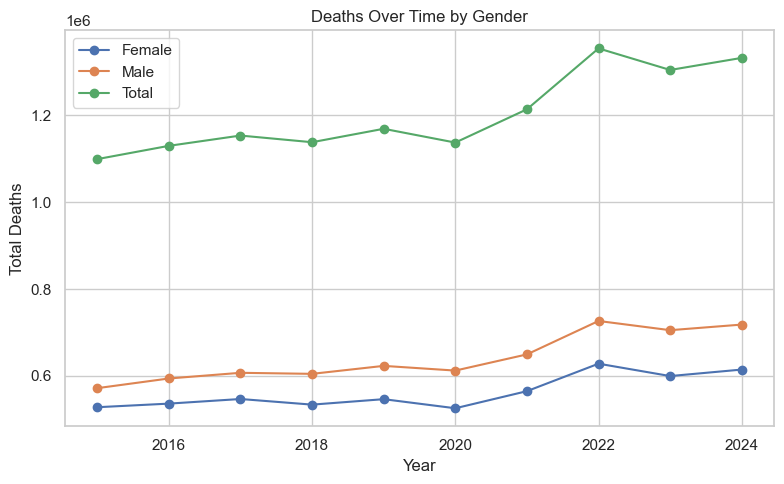

In [4]:
gender_trend = df.groupby(["Year", "Gender"])["Deaths"].sum().reset_index()

plt.figure(figsize=(8, 5))
for gender in gender_trend["Gender"].unique():
    temp = gender_trend[gender_trend["Gender"] == gender]
    plt.plot(temp["Year"], temp["Deaths"], marker="o", label=gender)

plt.title("Deaths Over Time by Gender")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.legend()
plt.tight_layout()
plt.savefig("Results/Figures/q1_deaths_over_time_by_gender.png")
plt.show()

###  Exploratory Data Analysis

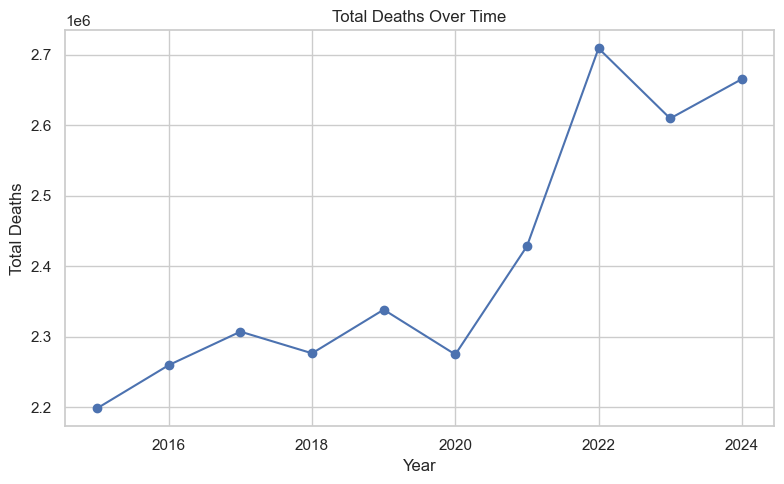

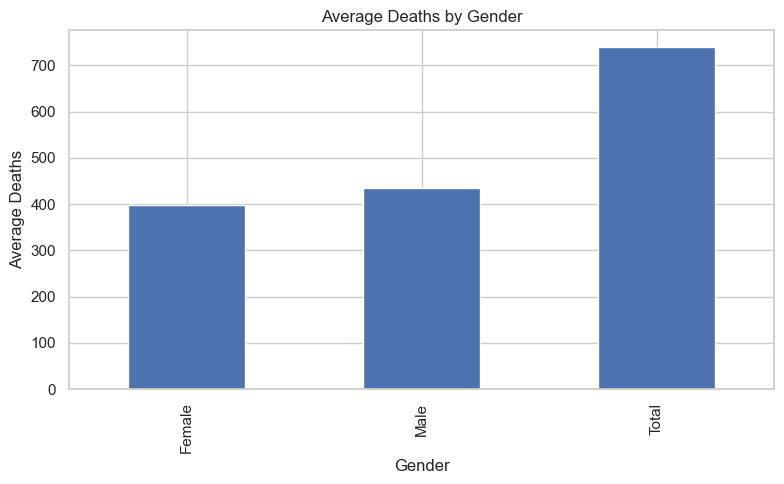

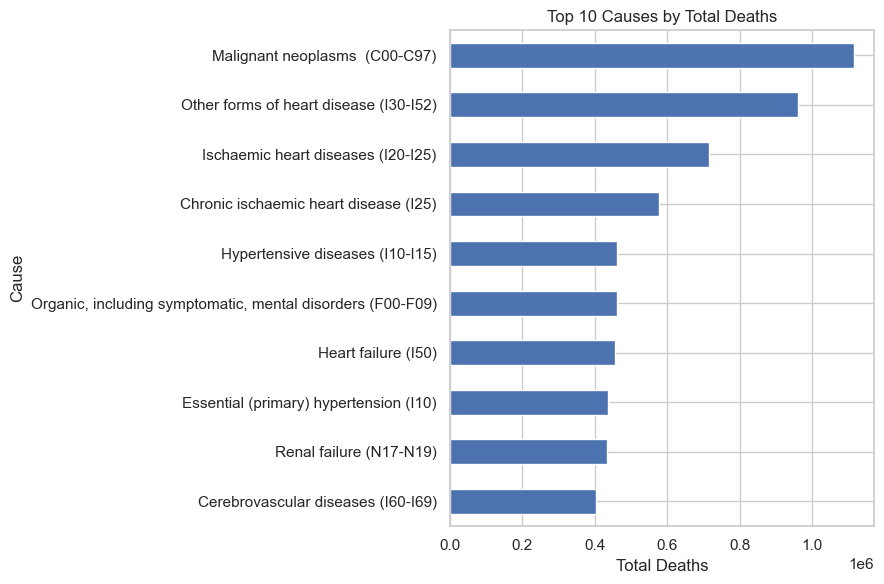

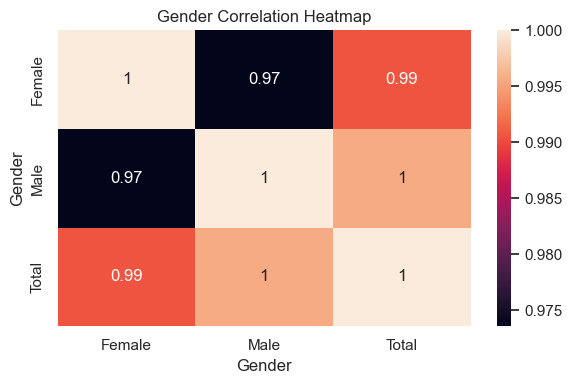

In [5]:
# Total deaths over time
trend = df.groupby("Year")["Deaths"].sum()
plt.figure(figsize=(8, 5))
trend.plot(marker="o")
plt.title("Total Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.tight_layout()
plt.savefig("Results/Figures/total_deaths_over_time.png")
plt.show()

# Average deaths by gender
plt.figure(figsize=(8, 5))
df.groupby("Gender")["Deaths"].mean().plot(kind="bar")
plt.title("Average Deaths by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Deaths")
plt.tight_layout()
plt.savefig("Results/Figures/average_deaths_by_gender.png")
plt.show()

# Top 10 causes of death
top_diseases = df.groupby("Cause")["Deaths"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 6))
top_diseases.plot(kind="barh")
plt.title("Top 10 Causes by Total Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Cause")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Results/Figures/top_10_causes.png")
plt.show()

# Gender Correlation Heatmap
pivot = df.pivot_table(values="Deaths", index="Year", columns="Gender", aggfunc="sum")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot.corr(), annot=True)
plt.title("Gender Correlation Heatmap")
plt.tight_layout()
plt.savefig("Results/Figures/gender_correlation_heatmap.png")
plt.show()

### 5. Regression Dataset Preparation

In [6]:
df["Cause_Code"] = df["Cause"].astype("category").cat.codes
X = df[["Year", "Gender_Code", "Cause_Code"]]
y = df["Deaths"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training (Linear, Multiple, Ridge, Random Forest)

In [7]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train[["Year"]], y_train)
linear_pred = linear_model.predict(X_test[["Year"]])
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

# Linear Regression (Full Features)
linear_full = LinearRegression()
linear_full.fit(X_train, y_train)
linear_full_pred = linear_full.predict(X_test)
linear_full_rmse = np.sqrt(mean_squared_error(y_test, linear_full_pred))
linear_full_r2 = r2_score(y_test, linear_full_pred)

# Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
multi_pred = multi_model.predict(X_test)
multi_rmse = np.sqrt(mean_squared_error(y_test, multi_pred))
multi_r2 = r2_score(y_test, multi_pred)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

### MODEL 5: Poisson Regression

In [8]:
X_poisson = sm.add_constant(X)
poisson_model = sm.GLM(y, X_poisson, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

print("\nMODEL 5: Poisson Regression")
print(poisson_results.summary())


MODEL 5: Poisson Regression
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                45237
Model:                            GLM   Df Residuals:                    45233
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.0656e+07
Date:                Mon, 27 Apr 2026   Deviance:                   1.0108e+08
Time:                        23:55:45   Pearson chi2:                 4.09e+08
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -30.201

### Model Comparison and Visualization

                        Model         RMSE        R2               AIC
0          Linear (Year only)  2505.669371 -0.000016               N/A
1      Linear (Full Features)  2499.685872  0.004754               N/A
2  Multiple Linear Regression  2499.685872  0.004754               N/A
3            Ridge Regression  2499.685971  0.004754               N/A
4    Random Forest Regression   210.105741  0.992969               N/A
5          Poisson Regression          N/A       N/A  101312832.218467


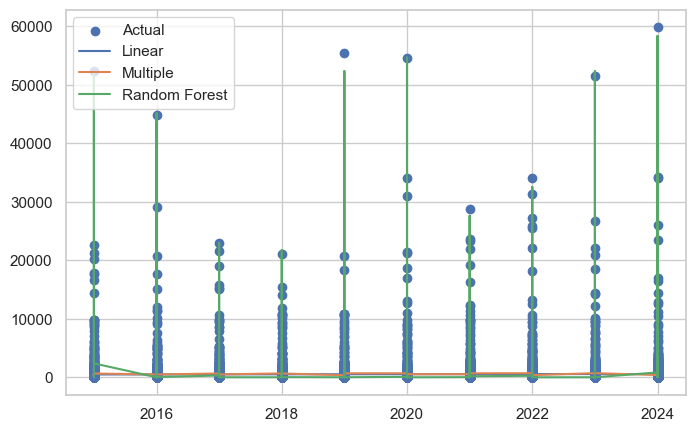

In [9]:
comparison = pd.DataFrame({
    "Model": ["Linear (Year only)", "Linear (Full Features)", "Multiple Linear Regression", "Ridge Regression", "Random Forest Regression", "Poisson Regression"],
    "RMSE": [linear_rmse, linear_full_rmse, multi_rmse, ridge_rmse, rf_rmse, "N/A"],
    "R2": [linear_r2, linear_full_r2, multi_r2, ridge_r2, rf_r2, "N/A"],
    "AIC": ["N/A", "N/A", "N/A", "N/A", "N/A", poisson_results.aic]
})

print(comparison)
comparison.to_csv("Results/model_comparison_results.csv", index=False)

# Actual vs Predicted Plot
plot_df = pd.DataFrame({
    "Year": X_test["Year"], "Actual": y_test, 
    "Linear_Predicted": linear_pred, "Multiple_Predicted": multi_pred, "RandomForest_Predicted": rf_pred
}).sort_values("Year")

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["Year"], plot_df["Actual"], label="Actual")
plt.plot(plot_df["Year"], plot_df["Linear_Predicted"], label="Linear")
plt.plot(plot_df["Year"], plot_df["Multiple_Predicted"], label="Multiple")
plt.plot(plot_df["Year"], plot_df["RandomForest_Predicted"], label="Random Forest")
plt.legend()
plt.savefig("Results/Figures/actual_vs_predicted_models.png")
plt.show()

### Statistical Testing and Q2 Analysis

Paired T-Test: 0.5642866491037803


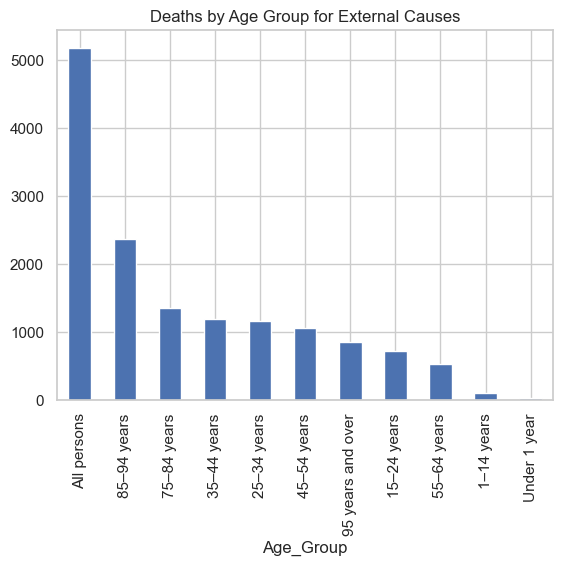

In [10]:
# T-Test
linear_error = abs(y_test - linear_pred)
multi_error = abs(y_test - multi_pred)
t_stat, p_value = ttest_rel(linear_error, multi_error)
print(f"Paired T-Test: {p_value}")

# Q2: Age and External Causes
table_1_3_path = os.path.join(base_dir, "Datasets/table_1_3_cleaned.csv")
if os.path.exists(table_1_3_path):
    df_age = pd.read_csv(table_1_3_path)
    ext_keywords = ["accident", "injury", "external", "transport", "fall", "suicide", "assault"]
    df_external = df_age[df_age["Cause"].astype(str).str.lower().str.contains("|".join(ext_keywords), na=False)]
    age_analysis = df_external.groupby("Age_Group")["Total_Deaths"].sum().sort_values(ascending=False)
    
    age_analysis.plot(kind="bar")
    plt.title("Deaths by Age Group for External Causes")
    plt.show()

### Q3-Q4: Cancer Classification and Trend Analysis

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Q3: Cancer Classification
df["Cancer_Label"] = np.where(df["Cause"].astype(str).str.contains("cancer|neoplasm|tumour|tumor|malignant", case=False, na=False), 1, 0)
X_class = df[["Year", "Gender_Code", "Cause_Code"]]
y_class = df["Cancer_Label"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=5).fit(X_train_c, y_train_c)
print(classification_report(y_test_c, clf.predict(X_test_c)))

# Q4: Increasing Trends
slopes = {cause: LinearRegression().fit(df[df["Cause"] == cause][["Year"]], df[df["Cause"] == cause]["Deaths"]).coef_[0] 
          for cause in df["Cause"].unique() if len(df[df["Cause"] == cause]) > 1}
slope_df = pd.DataFrame(list(slopes.items()), columns=["Cause", "Slope"])
slope_df.sort_values(by="Slope", ascending=False).head(10).to_csv("Results/q4_top_increasing_causes.csv", index=False)

print("All analysis completed.")

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8349
           1       1.00      0.93      0.97       699

    accuracy                           0.99      9048
   macro avg       1.00      0.97      0.98      9048
weighted avg       0.99      0.99      0.99      9048

All analysis completed.
